In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from conus_biomass import dir_info
from conus_biomass.make_figures import figure_settings
from conus_biomass.process_outputs.generate_state_csv import STATE_LIST as state_list

In [2]:
figure_settings.apply_style()

In [3]:
OUT_DIR = "../figure_data/Figure_S_state_timeseries/"
os.makedirs(OUT_DIR, exist_ok=True)

# Generate data

### Calculate time series from our analysis

In [4]:
dir_processed_model_output = dir_info.dir_model_output[:-1] + "_processed/"

for i in np.arange(0, 50):
    model_suffix = f"_{i:04d}"
    df = pd.read_csv(dir_processed_model_output + "MMTC_our_study" + model_suffix + ".csv")
    df = df.drop(columns=["Unnamed: 0"])
    df["model_suffix"] = model_suffix
    if i == 0:
        df_all = df
    else:
        df_all = pd.concat([df_all, df])

In [ ]:
df_mean = (
    df.groupby(["model_suffix", "state_abbr", "year"])["live_biomass_MMT"].mean().reset_index()
)

df_min = df.groupby(["model_suffix", "state_abbr", "year"])["live_biomass_MMT"].min().reset_index()

df_max = df.groupby(["model_suffix", "state_abbr", "year"])["live_biomass_MMT"].min().reset_index()

In [6]:
df_all.to_csv(OUT_DIR + "state_level_dataset.csv")

### Calculate time series from USFS datasets

In [7]:
FRF_state = pd.read_csv(dir_info.dir_walters + "FRF_stock_by_State.csv")

In [8]:
state_crosswalk = pd.read_csv(dir_info.dir_lookups + "state_abbreviation_crosswalk.csv")

In [ ]:
for i, state_abr in enumerate(state_list):
    state = state_crosswalk[state_crosswalk.Abbreviation == state_abr]["State"].values[0]
    FRF_state_agb = FRF_state[FRF_state["Carbon Pools"] == "Aboveground Biomass"]
    FRF_state_one_state = FRF_state_agb[FRF_state_agb["State"].isin([state])].drop(
        columns=["Carbon Pools"]
    )
    state_stocks = FRF_state_one_state.drop(columns=["State"]).sum()
    state_stocks.index = state_stocks.index.astype(int)

    df_state = pd.DataFrame(
        {
            "live_biomass_MMT": state_stocks,
            "year": state_stocks.index,
        }
    )
    df_state["state_abbr"] = state_abr

    if i == 0:
        df_all_USFS_EPA = df_state
    else:
        df_all_USFS_EPA = pd.concat([df_all_USFS_EPA, df_state])

df_all_USFS_EPA["estimate_type"] = "USFS_EPA"

In [10]:
df_all_USFS_EPA.to_csv(OUT_DIR + "MMTC_v6_1000m.csv")

# Load data

In [4]:
df_all = pd.read_csv(OUT_DIR + "state_level_dataset.csv")
df_all_USFS_EPA = pd.read_csv(OUT_DIR + "MMTC_v6_1000m.csv")
years = np.arange(2005, 2023)

In [5]:
df_all_USFS_EPA = df_all_USFS_EPA.rename(columns={"Unnamed: 0": "Year"})
df_all_USFS_EPA = df_all_USFS_EPA.set_index("Year")

# State-level plots

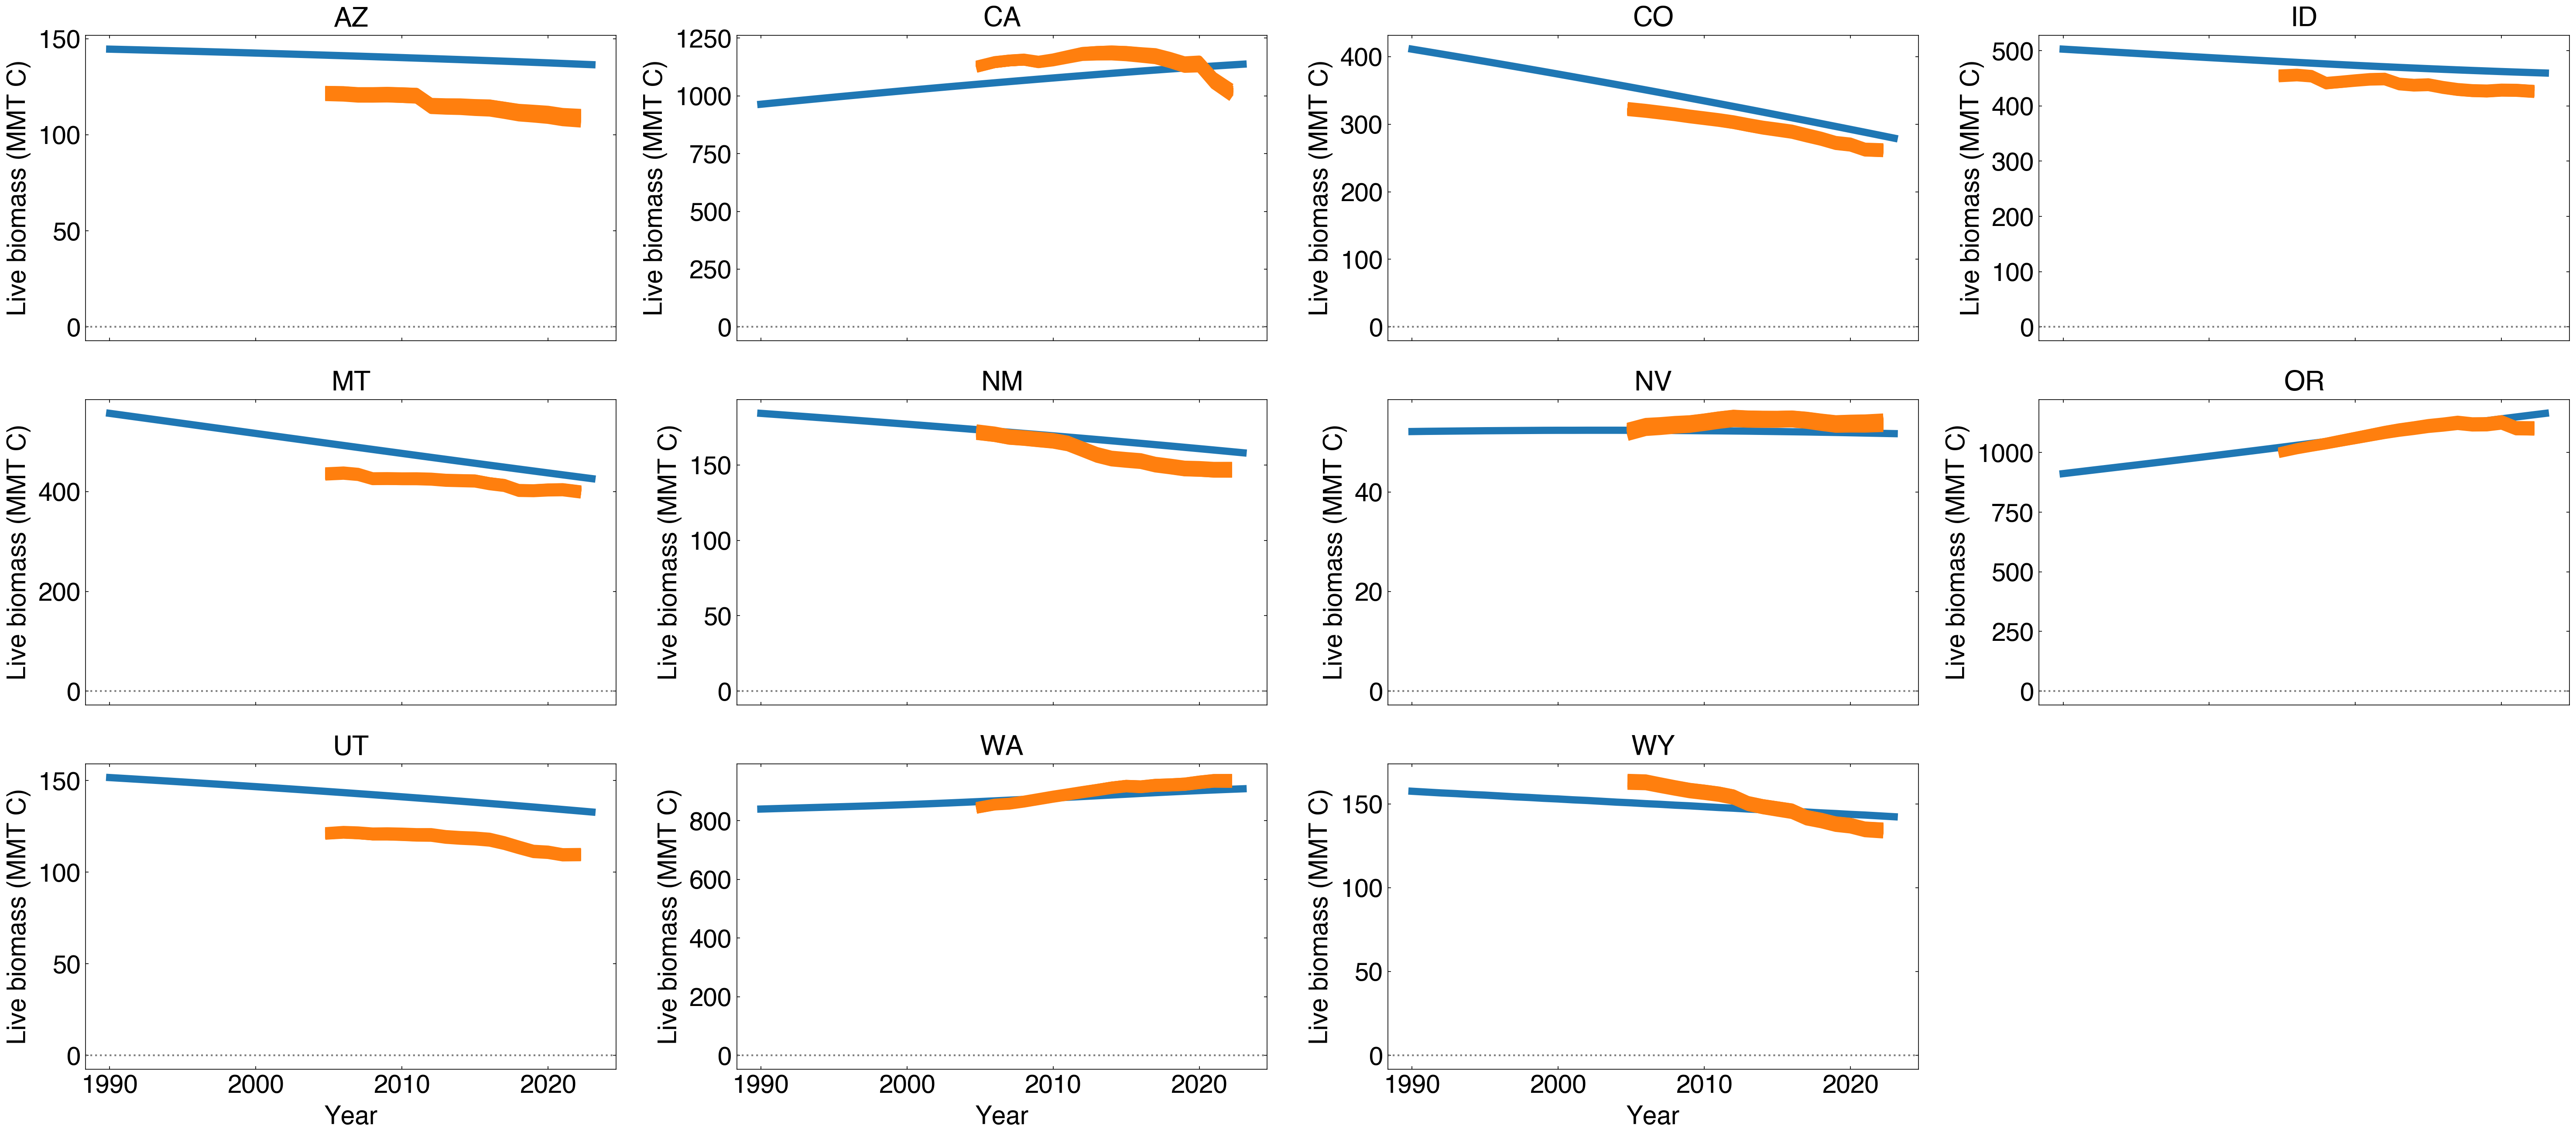

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(40, 18), sharex=True)  # sharey=True,
for i, state in enumerate(state_list):
    epa_vals = df_all_USFS_EPA[df_all_USFS_EPA["state_abbr"] == state]["live_biomass_MMT"]

    plt.subplot(3, 4, i + 1)
    plt.title(state)
    epa_vals.plot()

    for i in np.arange(0, 50):
        model_suffix = f"_{i:04d}"
        our_vals = df_all[
            (df_all["state_abbr"] == state) * (df_all["model_suffix"] == model_suffix)
        ]["live_biomass_MMT"]
        plt.plot(years, our_vals, color="C1")
    plt.axhline(y=0, linestyle=":", color="gray", linewidth=2)
    plt.ylabel("Live biomass (MMT C)")
axes.flat[-1].set_visible(False)
plt.tight_layout()

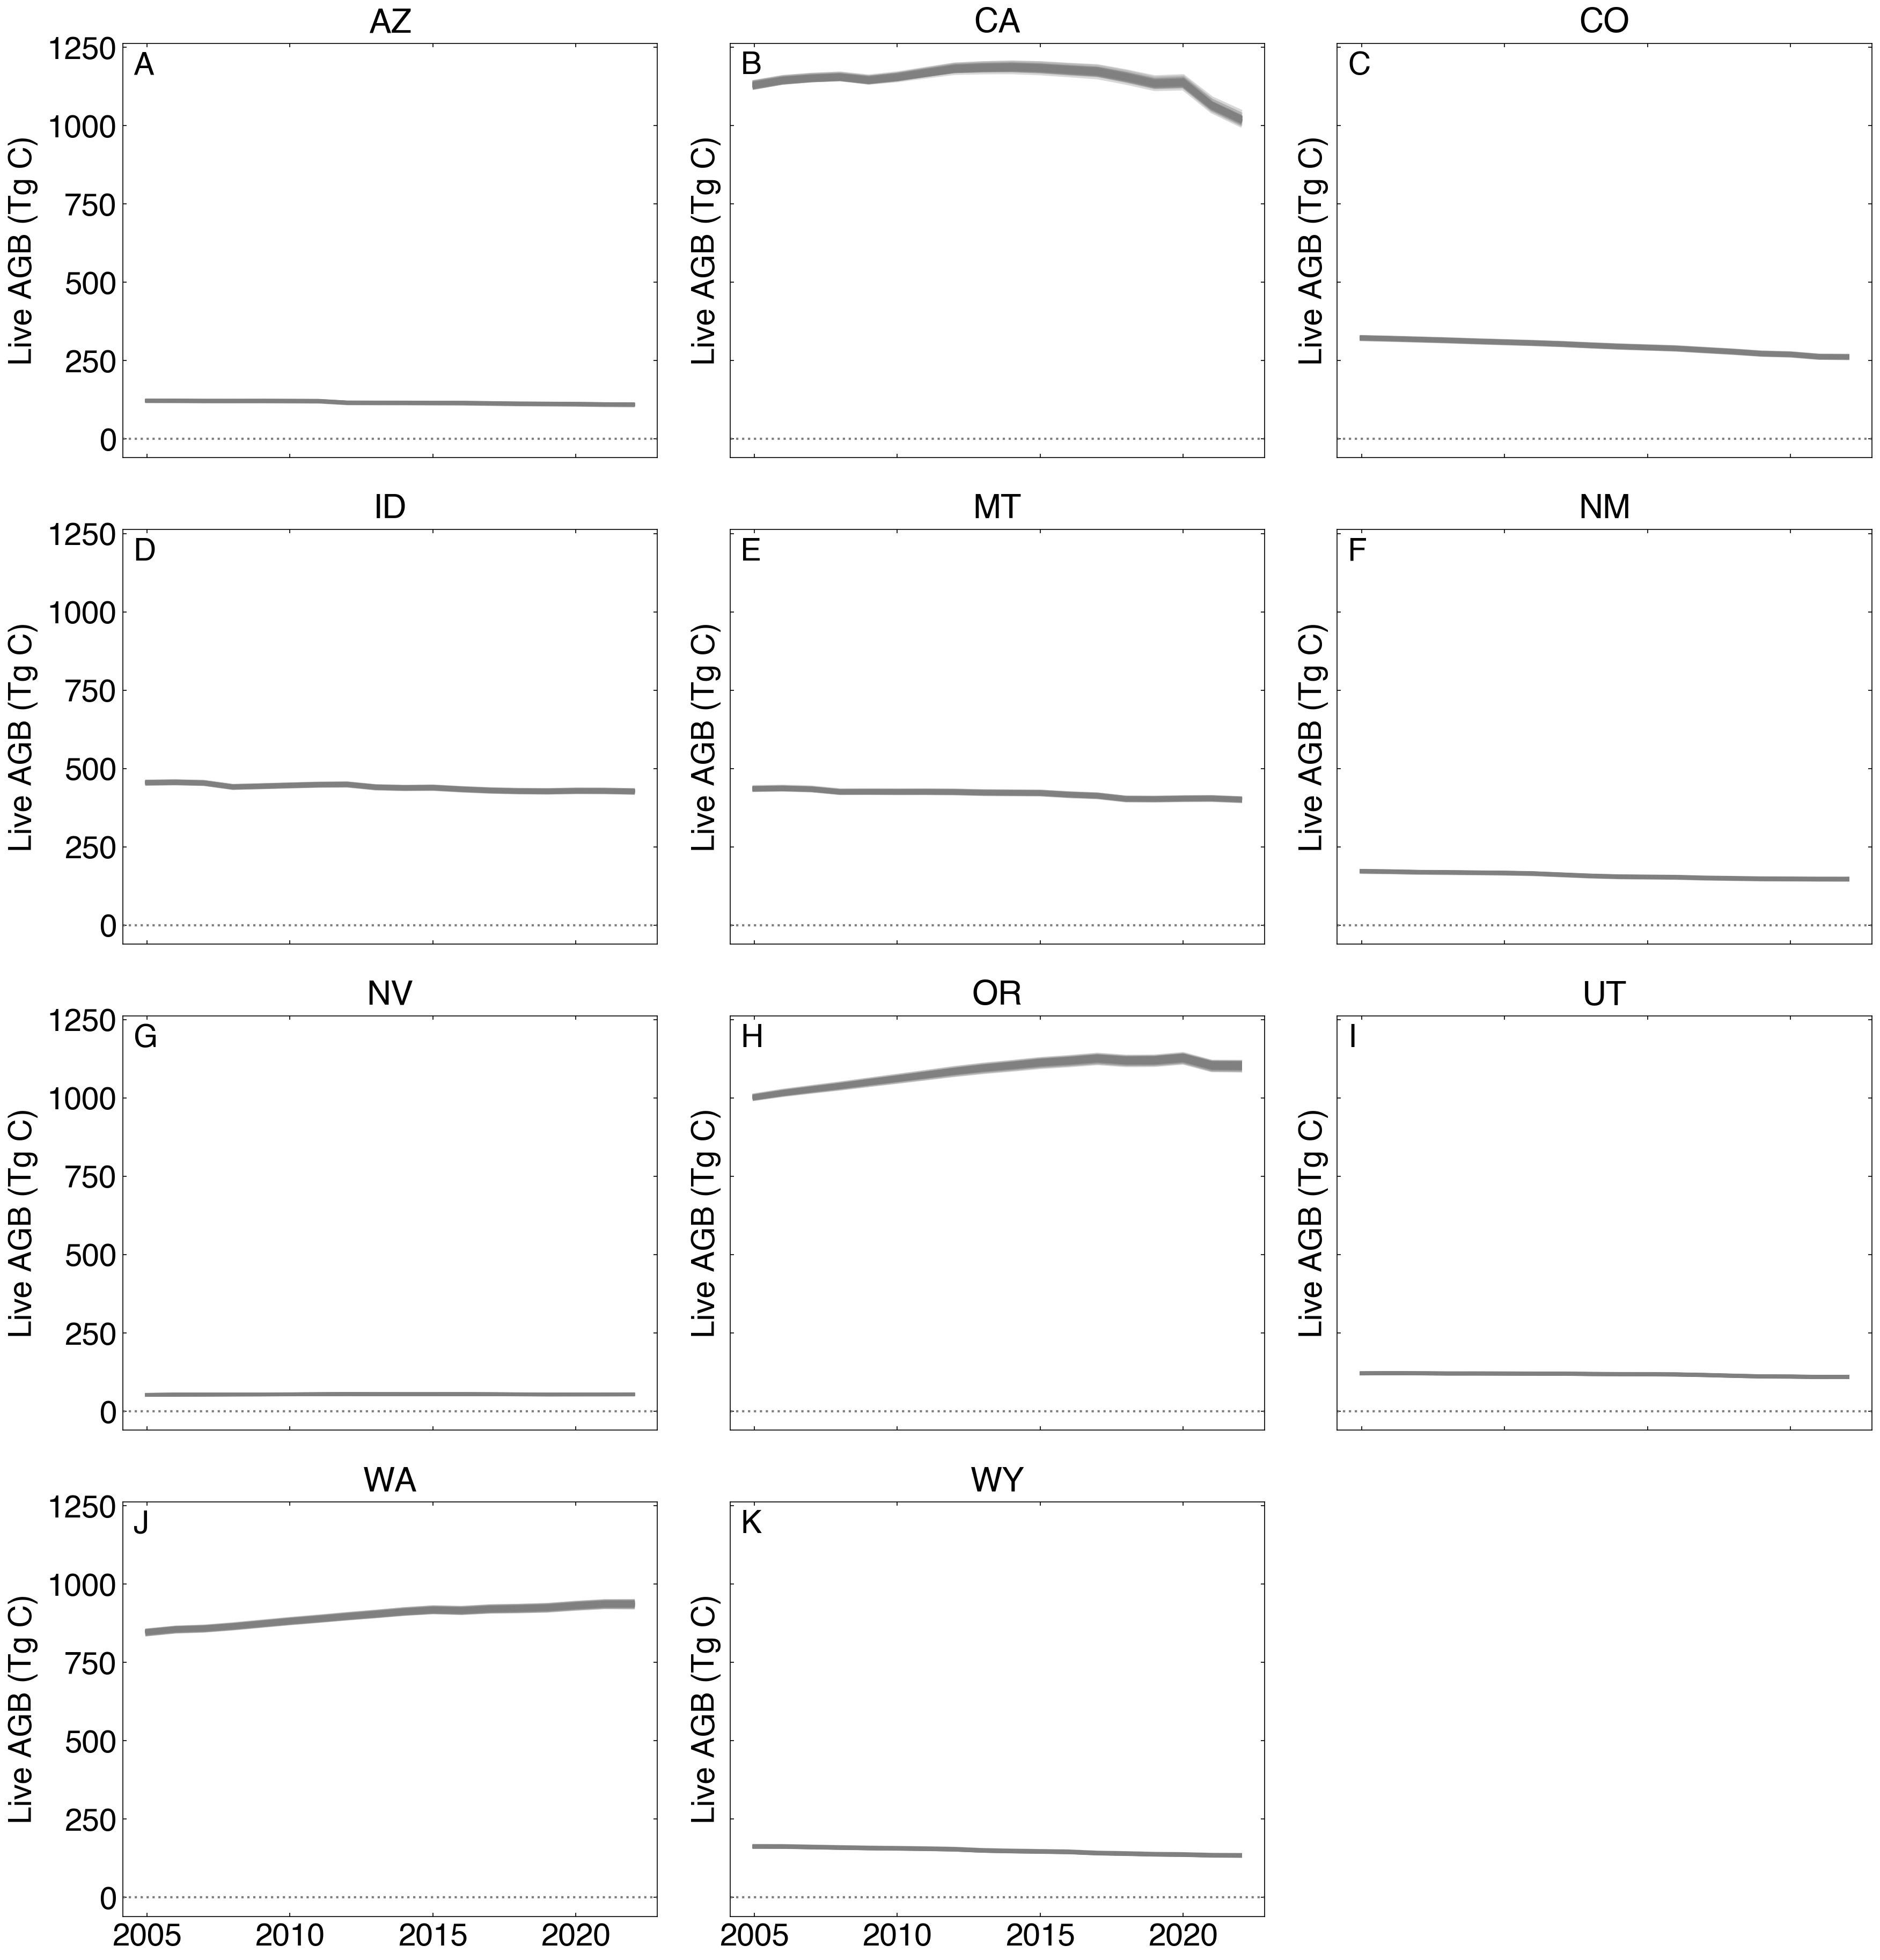

In [25]:
fig, axes = plt.subplots(4, 3, figsize=(24, 25), sharey=True, sharex=True)
for i, state in enumerate(state_list):
    epa_vals = df_all_USFS_EPA[df_all_USFS_EPA["state_abbr"] == state]["live_biomass_MMT"]

    plt.subplot(4, 3, i + 1)
    plt.title(state)
    # epa_vals.plot(label="Official US estimate")

    for i in np.arange(0, 50):
        model_suffix = f"_{i:04d}"
        our_vals = df_all[
            (df_all["state_abbr"] == state) * (df_all["model_suffix"] == model_suffix)
        ]["live_biomass_MMT"]
        plt.plot(years, our_vals, color="gray", alpha=0.3, linewidth=3)
    plt.axhline(y=0, linestyle=":", color="gray", linewidth=2)
    plt.ylabel("Live biomass (MMT C)")

panel_labels = [
    "A",
    "B",
    "C",
    "D",
    "E",
    "F",
    "G",
    "H",
    "I",
    "J",
    "K",
    "L",
    "M",
    "N",
    "O",
    "P",
    "Q",
    "R",
]

i = 0
for ax1 in axes:
    for ax in ax1:
        panel_label = panel_labels[i]
        ax.text(
            figure_settings.panel_x_offset,
            figure_settings.panel_y_offset,
            panel_label,
            transform=ax.transAxes,
            fontweight="bold",
            va="top",
        )

        ax.set_ylabel("Live AGB (Tg C)")
        i += 1

axes.flat[-1].set_visible(False)
plt.savefig(dir_info.dir_figures + "supp/Figure_S_state_timeseries_absolute.pdf")
plt.tight_layout()

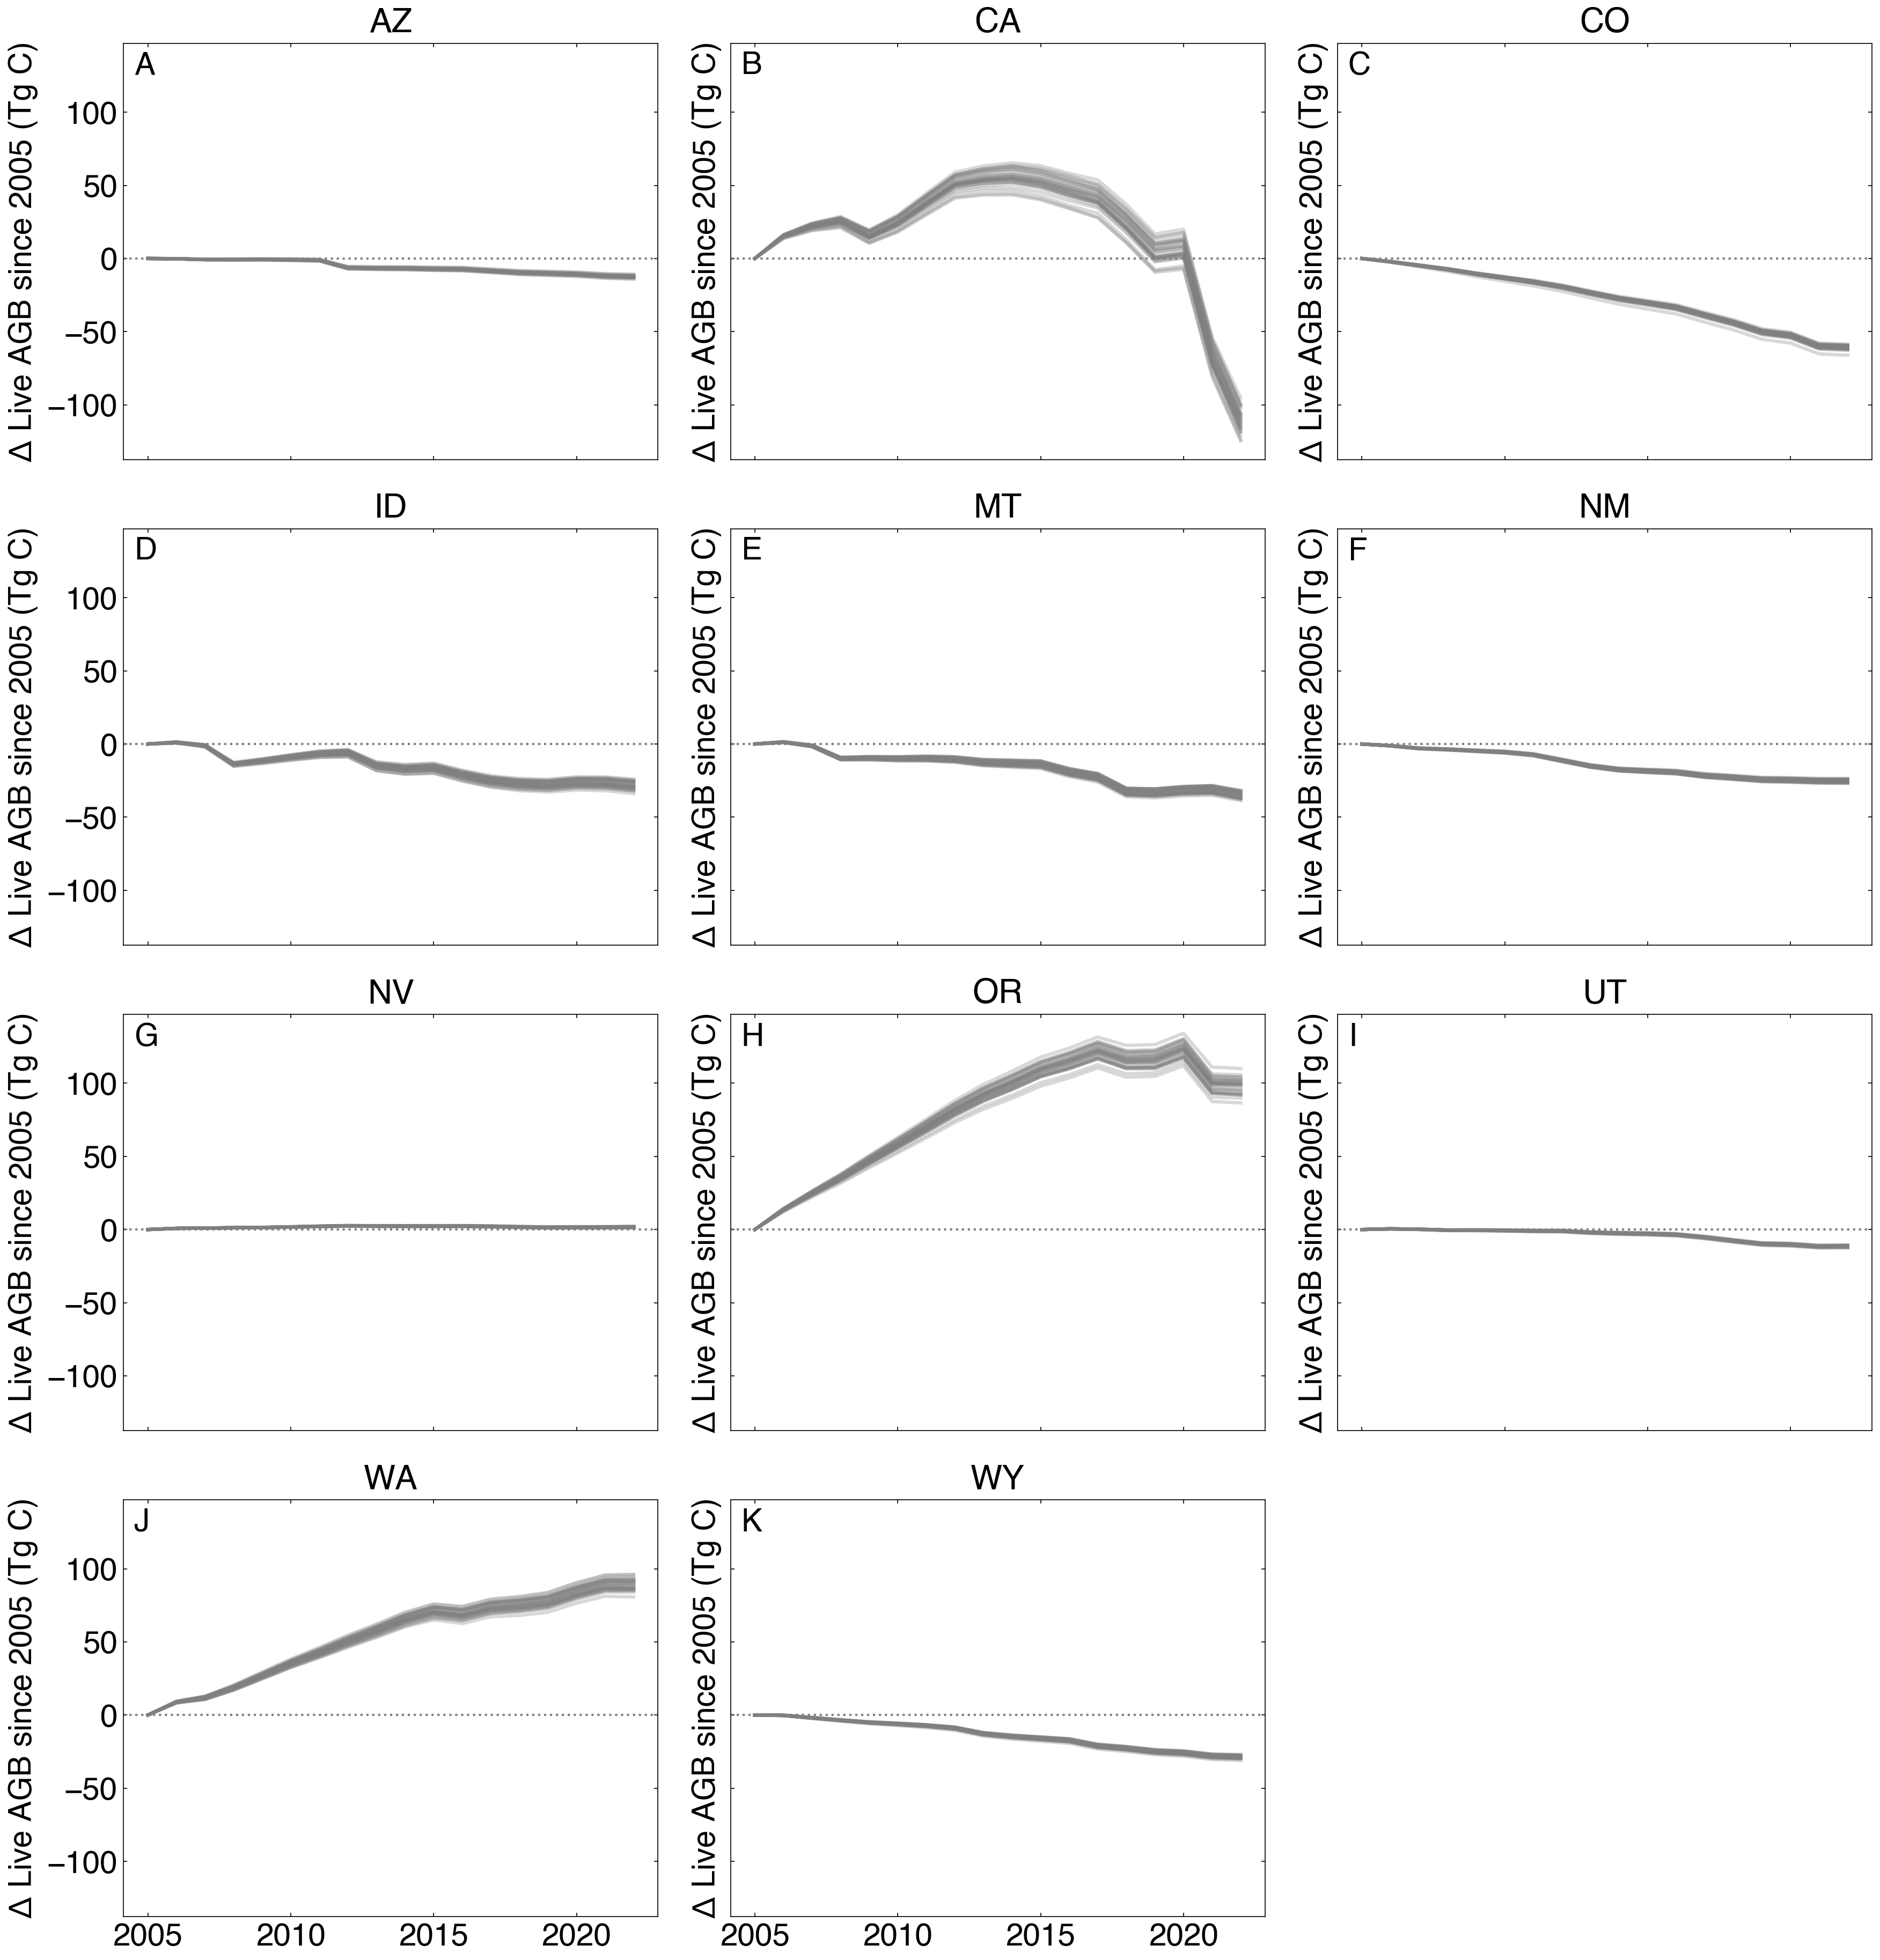

In [27]:
fig, axes = plt.subplots(4, 3, figsize=(24, 25), sharey=True, sharex=True)
for i, state in enumerate(state_list):
    epa_vals = df_all_USFS_EPA[df_all_USFS_EPA["state_abbr"] == state]["live_biomass_MMT"]

    plt.subplot(4, 3, i + 1)
    plt.title(state)
    # (epa_vals - epa_vals.values[15]).plot()
    plt.axhline(y=0, linestyle=":", color="gray", linewidth=2)
    plt.ylabel("Δ Live AGB since 2005 (Tg C)")
    for i in np.arange(0, 30):
        model_suffix = f"_{i:04d}"
        our_vals = df_all[
            (df_all["state_abbr"] == state) * (df_all["model_suffix"] == model_suffix)
        ]["live_biomass_MMT"]
        plt.plot(years, our_vals - our_vals.values[0], color="gray", alpha=0.3, linewidth=3)
axes.flat[-1].set_visible(False)

i = 0
for ax1 in axes:
    for ax in ax1:
        panel_label = panel_labels[i]
        ax.text(
            figure_settings.panel_x_offset,
            figure_settings.panel_y_offset,
            panel_label,
            transform=ax.transAxes,
            fontweight="bold",
            va="top",
        )

        i += 1
plt.tight_layout()
plt.savefig(dir_info.dir_figures + "supp/Figure_S_state_timeseries_deltas.pdf")